# Visualización de datos con Matplotlib
### Dataset: Encuesta de hogares Argentina — ingresos, gastos y condiciones socioeconómicas

> **¿Por qué Matplotlib?**
> Matplotlib es la librería de visualización más usada en el ecosistema Python. Es la base sobre la que se construyen otras librerías como Seaborn. Entender cómo funciona Matplotlib permite controlar con precisión cualquier aspecto de un gráfico: colores, escalas, etiquetas, anotaciones, disposición de paneles.

---

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
df = pd.read_csv('hogares_argentina.csv')
df_viz = df[df['ingreso_mensual'] < df['ingreso_mensual'].quantile(0.97)].copy()
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

---

##  Las dos interfaces de Matplotlib

> **Síntesis teórica**
>
> Matplotlib organiza los gráficos en dos objetos principales:
> - **Figure**: el contenedor general — la "hoja en blanco" que puede contener uno o más gráficos.
> - **Axes**: el área de dibujo concreta — con sus ejes, grilla, etiquetas y elementos visuales.
>
> Matplotlib tiene **dos interfaces** para crear gráficos:
>
> **Interfaz estilo MATLAB (`plt.`)** — basada en estado. Matplotlib mantiene un registro del axes activo internamente. Cada función `plt.algo()` actúa sobre ese axes activo sin que lo veamos explícitamente. Es rápida para gráficos simples pero puede generar confusión cuando hay múltiples paneles.
>
> **Interfaz orientada a objetos (`fig, ax`)** — explícita. Se trabaja directamente con los objetos `fig` y `ax`. Cada método se llama sobre el objeto concreto. Es la forma recomendada para cualquier gráfico que no sea trivial.
>
> **Regla práctica:** si el gráfico tiene más de un panel, o si vas a modificarlo después de crearlo, usá la interfaz orientada a objetos.

### 1.1 El mismo histograma con las dos interfaces

In [ ]:
# ── INTERFAZ MATLAB ──
# plt. actúa sobre el axes activo — Matplotlib lo mantiene internamente

plt.figure(figsize=(10, 4))             # crea una figura vacía
plt.hist(df_viz['ingreso_mensual'],     # dibuja sobre el axes activo
         bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.title('Distribución del ingreso mensual')  # modifica el axes activo
plt.xlabel('Ingreso ($ ARS)')
plt.ylabel('Frecuencia')
plt.axvline(df_viz['ingreso_mensual'].mean(),   color='red',    linestyle='--', label='Media')
plt.axvline(df_viz['ingreso_mensual'].median(), color='orange', linestyle='--', label='Mediana')
plt.legend()
plt.show()

In [ ]:
# ── INTERFAZ ORIENTADA A OBJETOS ──
# fig y ax son objetos Python — cada método se llama sobre el objeto concreto

fig, ax = plt.subplots(figsize=(10, 4))   # crea figure y axes explícitamente

ax.hist(df_viz['ingreso_mensual'],         # dibuja sobre ax (no sobre plt.)
        bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribución del ingreso mensual')  # set_title, no title
ax.set_xlabel('Ingreso ($ ARS)')                  # set_xlabel, no xlabel
ax.set_ylabel('Frecuencia')                       # set_ylabel, no ylabel
ax.axvline(df_viz['ingreso_mensual'].mean(),   color='red',    linestyle='--', label='Media')
ax.axvline(df_viz['ingreso_mensual'].median(), color='orange', linestyle='--', label='Mediana')
ax.legend()
plt.show()

### 1.2 Tabla de equivalencias — parámetros modificables

| Interfaz MATLAB (`plt.`) | Interfaz OO (`ax.`) | Qué controla |
|---|---|---|
| `plt.figure(figsize=)` | `fig, ax = plt.subplots(figsize=)` | Tamaño de la figura |
| `plt.title('texto')` | `ax.set_title('texto')` | Título del gráfico |
| `plt.xlabel('texto')` | `ax.set_xlabel('texto')` | Etiqueta eje X |
| `plt.ylabel('texto')` | `ax.set_ylabel('texto')` | Etiqueta eje Y |
| `plt.xlim(min, max)` | `ax.set_xlim(min, max)` | Rango del eje X |
| `plt.ylim(min, max)` | `ax.set_ylim(min, max)` | Rango del eje Y |
| `plt.legend()` | `ax.legend()` | Leyenda |
| `plt.axvline(x)` | `ax.axvline(x)` | Línea vertical de referencia |
| `plt.axhline(y)` | `ax.axhline(y)` | Línea horizontal de referencia |
| `plt.text(x, y, s)` | `ax.text(x, y, s)` | Texto en coordenadas |
| `plt.annotate(...)` | `ax.annotate(...)` | Texto con flecha |
| `plt.tight_layout()` | `plt.tight_layout()` | Ajuste automático de márgenes |
| `plt.show()` | `plt.show()` | Mostrar el gráfico |

> **Lo que cambia:** en la interfaz MATLAB, las funciones son de `plt.` y los nombres son directos (`title`, `xlabel`). En la orientada a objetos, se llaman sobre `ax` y tienen el prefijo `set_` (`set_title`, `set_xlabel`). Los métodos que no modifican el axes (`legend`, `axvline`, `axhline`, `text`, `annotate`) tienen el **mismo nombre** en ambas interfaces.

### 1.3 ¿Por qué usar la interfaz orientada a objetos? — múltiples paneles

In [ ]:
# Con la interfaz MATLAB es confuso saber sobre qué panel actúa cada comando
# Con la interfaz OO cada panel es un objeto separado — no hay ambigüedad

fig, axes = plt.subplots(1, 2, figsize=(13, 5))   # dos axes en una figura

# Panel izquierdo — axes[0]
axes[0].hist(df_viz['ingreso_mensual'], bins=35,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Ingreso mensual')
axes[0].set_xlabel('$ ARS')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_viz['ingreso_mensual'].median(),
                color='orange', linestyle='--', linewidth=1.8, label='Mediana')
axes[0].legend()

# Panel derecho — axes[1]
axes[1].hist(df_viz['gasto_alimentos'], bins=35,
             color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Gasto en alimentos')
axes[1].set_xlabel('$ ARS')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df_viz['gasto_alimentos'].median(),
                color='orange', linestyle='--', linewidth=1.8, label='Mediana')
axes[1].legend()

plt.suptitle('Comparación de distribuciones — interfaz orientada a objetos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** Con la interfaz orientada a objetos cada panel es un objeto `ax` separado — `axes[0]` y `axes[1]`. Cada comando actúa exactamente sobre el panel que especificamos. Con la interfaz MATLAB esto requeriría `plt.subplot()` para cambiar el axes activo en cada paso, lo que es mucho más propenso a errores.

### 1.4 Estilos visuales

In [ ]:
# plt.style.use() aplica un estilo globalmente a todos los gráficos siguientes
# plt.style.context() lo aplica solo dentro del bloque with — sin efecto global
print("Algunos estilos disponibles:")
print([s for s in plt.style.available if 'seaborn' not in s][:8])

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, estilo in zip(axes, ['bmh', 'ggplot', 'classic']):
    with plt.style.context(estilo):
        ax.hist(df_viz['ingreso_mensual'], bins=30, color='steelblue', alpha=0.8)
        ax.set_title(f"style='{estilo}'")
        ax.set_xlabel('Ingreso ($ ARS)')

plt.suptitle('Comparación de estilos visuales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** El estilo controla fondo, grilla, tipografía y paleta. `plt.style.context()` como context manager aplica el estilo solo dentro del bloque `with` — útil para comparar estilos sin que uno afecte al siguiente. Para el trabajo diario, `plt.style.use('ggplot')` o `plt.rcParams` al inicio del notebook es suficiente.

---

##  — Gráficos de líneas y dispersión

> **Síntesis teórica**
>
> **`plt.plot` / `ax.plot` — gráfico de líneas**
> Une los puntos con líneas. Se usa para mostrar evolución o tendencia a lo largo de una secuencia ordenada. Parámetros clave: `linestyle`, `color`, `marker`, `linewidth`, `markersize`.
>
> **`plt.scatter` / `ax.scatter` — diagrama de dispersión**
> Cada observación es un punto sin conectar. Permite variar el color (`c`) y el tamaño (`s`) de cada punto individualmente — ideal para codificar una tercera variable visualmente.
>
> **Diferencia clave:** `plot` asume que el orden de los datos importa (los conecta en secuencia). `scatter` no asume orden — cada punto es independiente.

### 2.1 Gráfico de líneas — ingreso promedio por región

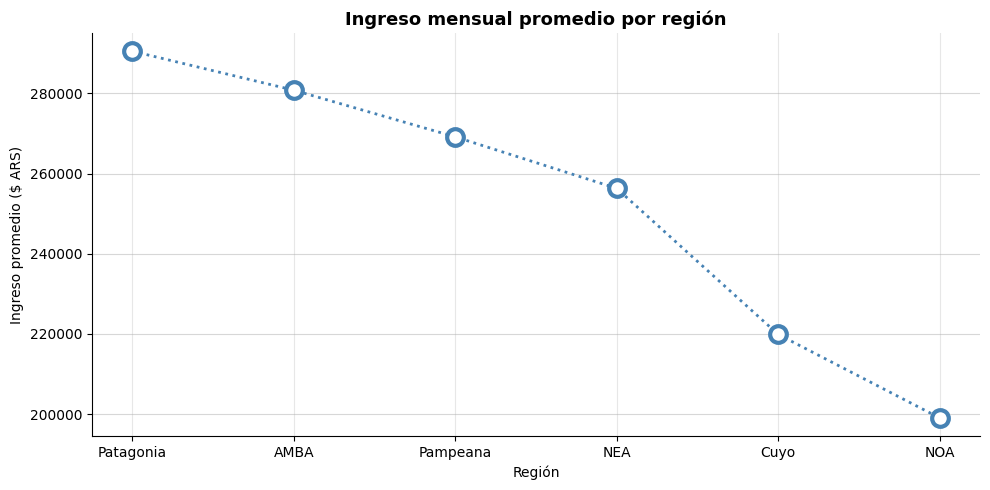

In [ ]:
ingreso_region = (df.groupby('region')['ingreso_mensual']
                  .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ingreso_region.index,    # eje X: categorías
        ingreso_region.values,   # eje Y: valores
        marker='o',              # marcador en cada punto
        linestyle=':',           # tipo de línea: sólida
        linewidth= 2,             # grosor de la línea
        color='steelblue',       # color de la línea
        markersize=12,            # tamaño del marcador
        markerfacecolor='white', # color de relleno del marcador
        markeredgecolor='steelblue',  # color del borde del marcador
        markeredgewidth=3)       # grosor del borde del marcador

ax.set_title('Ingreso mensual promedio por región', fontsize=13, fontweight='bold')
ax.set_xlabel('Región')
ax.set_ylabel('Ingreso promedio ($ ARS)')
ax.yaxis.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### 2.2 Estilos de línea y color

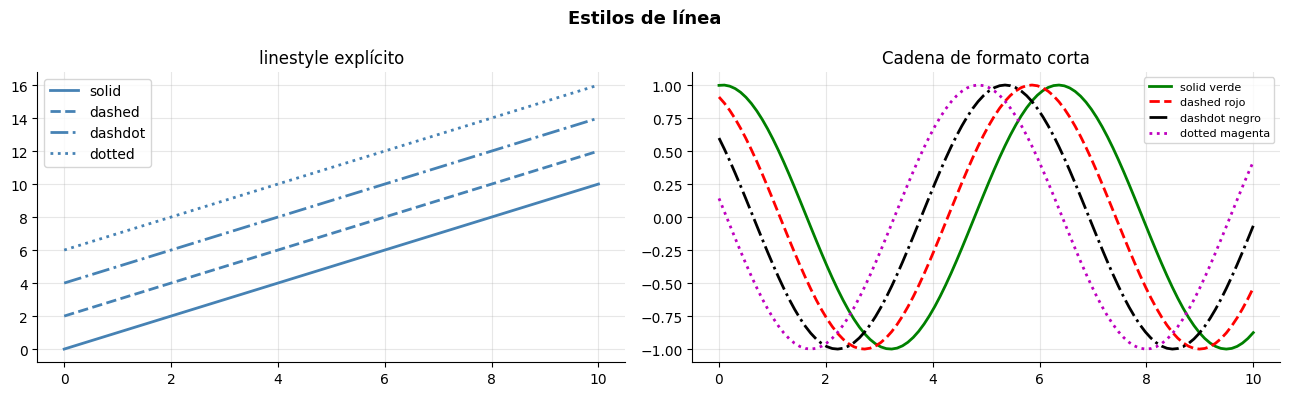

In [ ]:
x = np.linspace(0, 10, 100)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: parámetros explícitos
for i, (ls, label) in enumerate(zip(['-', '--', '-.', ':'],
                                     ['solid', 'dashed', 'dashdot', 'dotted'])):
    axes[0].plot(x, x + i*2, linestyle=ls, color='steelblue',
                 linewidth=2, label=label)
axes[0].set_title('linestyle explícito')
axes[0].legend()

# Panel derecho: cadena de formato corta (color + estilo en un string)
for fmt, label in zip(['-g', '--r', '-.k', ':m'],
                       ['solid verde', 'dashed rojo', 'dashdot negro', 'dotted magenta']):
    axes[1].plot(x, np.sin(x + i*0.5), fmt, linewidth=2, label=label)
    i += 1
axes[1].set_title('Cadena de formato corta')
axes[1].legend(fontsize=8)

plt.suptitle('Estilos de línea', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** La cadena de formato `'-g'` combina linestyle y color en un solo argumento. El primer carácter o caracteres definen el estilo (`-`, `--`, `-.`, `:`) y la letra final el color (`g`=green, `r`=red, `k`=black, `m`=magenta, `b`=blue, `c`=cyan). Es conveniente para gráficos rápidos pero para mayor control usá `linestyle=` y `color=` por separado.

### 2.3 Scatter — ingreso vs. gasto en alimentos por tipo de empleo

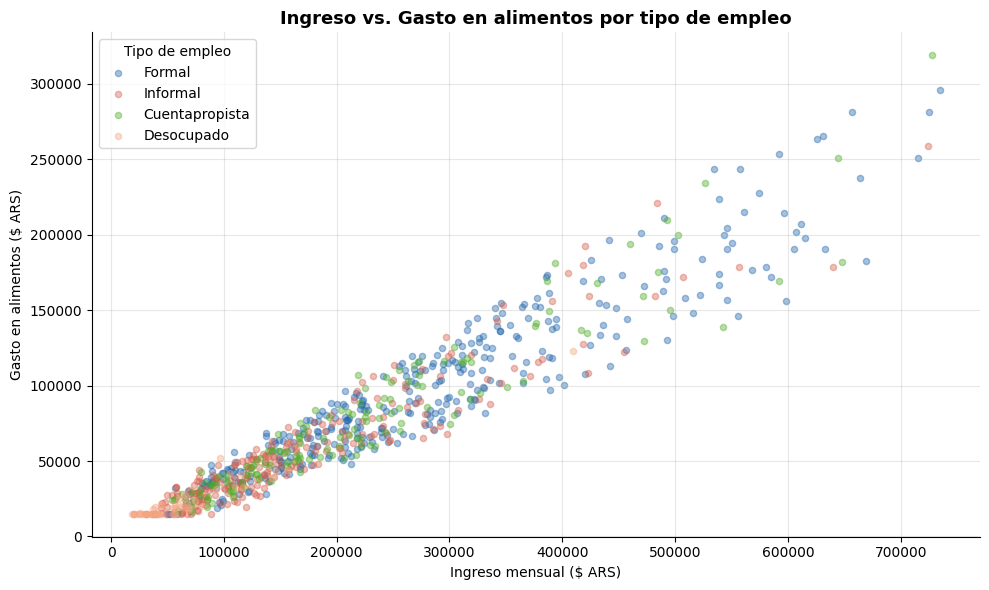

In [ ]:
colores_map = {'Formal': '#2166ac', 'Informal': '#d6604d',
               'Cuentapropista': '#4dac26', 'Desocupado': '#f4a582'}

fig, ax = plt.subplots(figsize=(10, 6))

for tipo, color in colores_map.items():
    mask = df_viz['tipo_empleo'] == tipo
    ax.scatter(df_viz.loc[mask, 'ingreso_mensual'],  # eje X
               df_viz.loc[mask, 'gasto_alimentos'],  # eje Y
               c=color,    # color de los puntos
               alpha=0.4,  # transparencia
               s=20,       # tamaño de los puntos
               label=tipo)

ax.set_title('Ingreso vs. Gasto en alimentos por tipo de empleo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ingreso mensual ($ ARS)')
ax.set_ylabel('Gasto en alimentos ($ ARS)')
ax.legend(title='Tipo de empleo')
plt.tight_layout()
plt.show()

> **Interpretación:** El scatter con color por tipo de empleo muestra que los puntos azules (Formal) se concentran en la parte superior derecha — ingresos y gastos más altos. Los naranjas (Desocupado) están comprimidos abajo a la izquierda. El parámetro `alpha=0.4` hace los puntos semitransparentes para que las zonas densas sean visibles aunque haya superposición.

---

##  — Histogramas

> **Síntesis teórica**
>
> **`ax.hist` — histograma**
> Parámetros clave:
> - `bins`: cantidad de intervalos. Más bins = más detalle pero más ruido.
> - `alpha`: transparencia — útil para superponer distribuciones.
> - `edgecolor`: color del borde de cada barra.
> - `density`: si es `True`, normaliza el eje Y como densidad de probabilidad.
> - `histtype`: `'bar'` (relleno), `'step'` (solo contorno), `'stepfilled'` (contorno relleno).
>
> **`ax.hist2d` / `ax.hexbin`** — para distribución conjunta de dos variables cuando hay muchos puntos superpuestos.

### 3.1 Histograma — distribución del ingreso

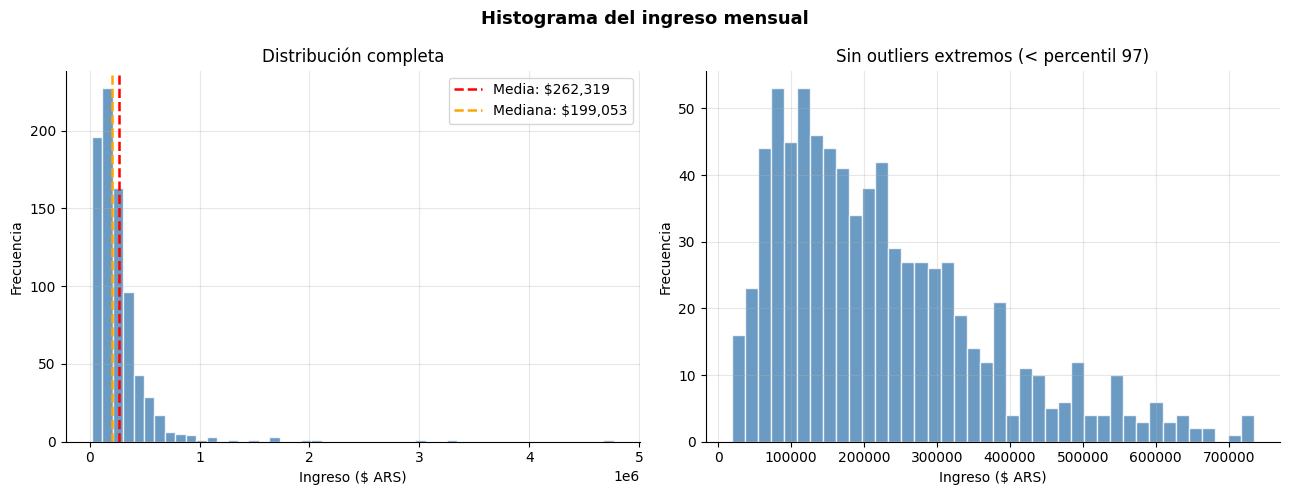

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: distribución completa
axes[0].hist(df['ingreso_mensual'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.8)
media   = df['ingreso_mensual'].mean()
mediana = df['ingreso_mensual'].median()
axes[0].axvline(media,   color='red',    linestyle='--', linewidth=1.8,
                label=f'Media: ${media:,.0f}')
axes[0].axvline(mediana, color='orange', linestyle='--', linewidth=1.8,
                label=f'Mediana: ${mediana:,.0f}')
axes[0].set_title('Distribución completa')
axes[0].set_xlabel('Ingreso ($ ARS)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Panel derecho: sin outliers extremos
p97 = df['ingreso_mensual'].quantile(0.97)
axes[1].hist(df[df['ingreso_mensual'] < p97]['ingreso_mensual'],
             bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Sin outliers extremos (< percentil 97)')
axes[1].set_xlabel('Ingreso ($ ARS)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Histograma del ingreso mensual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** Este es el mismo histograma que vimos en el EDA — pero ahora el foco está en cómo se construye con Matplotlib. La media ($262k) supera a la mediana ($199k) porque los outliers altos tiran el promedio. `axvline` traza líneas verticales en los valores de media y mediana directamente sobre el histograma — ese es un ejemplo de personalización que Matplotlib permite con precisión.

### 3.2 Superponer distribuciones con alpha

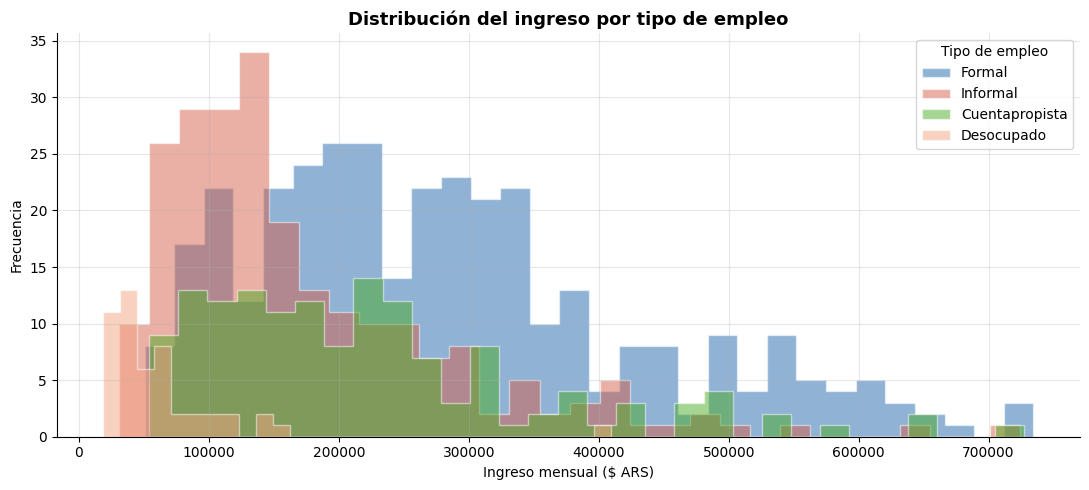

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

colores = {'Formal': '#2166ac', 'Informal': '#d6604d',
           'Cuentapropista': '#4dac26', 'Desocupado': '#f4a582'}

for tipo, color in colores.items():
    datos = df_viz[df_viz['tipo_empleo'] == tipo]['ingreso_mensual']
    # histtype='stepfilled': contorno + relleno semitransparente
    ax.hist(datos, bins=30, alpha=0.5, color=color,
            edgecolor='white', label=tipo, histtype='stepfilled')

ax.set_title('Distribución del ingreso por tipo de empleo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ingreso mensual ($ ARS)')
ax.set_ylabel('Frecuencia')
ax.legend(title='Tipo de empleo')
plt.tight_layout()
plt.show()

> **Interpretación:** `alpha=0.5` hace semitransparentes las barras. Donde se superponen las distribuciones los colores se mezclan, revelando la zona de solapamiento. `histtype='stepfilled'` combina el contorno de `step` con el relleno de `bar` — produce un resultado más limpio que `'bar'` cuando hay superposición.

### 3.3 Histograma 2D y hexbin

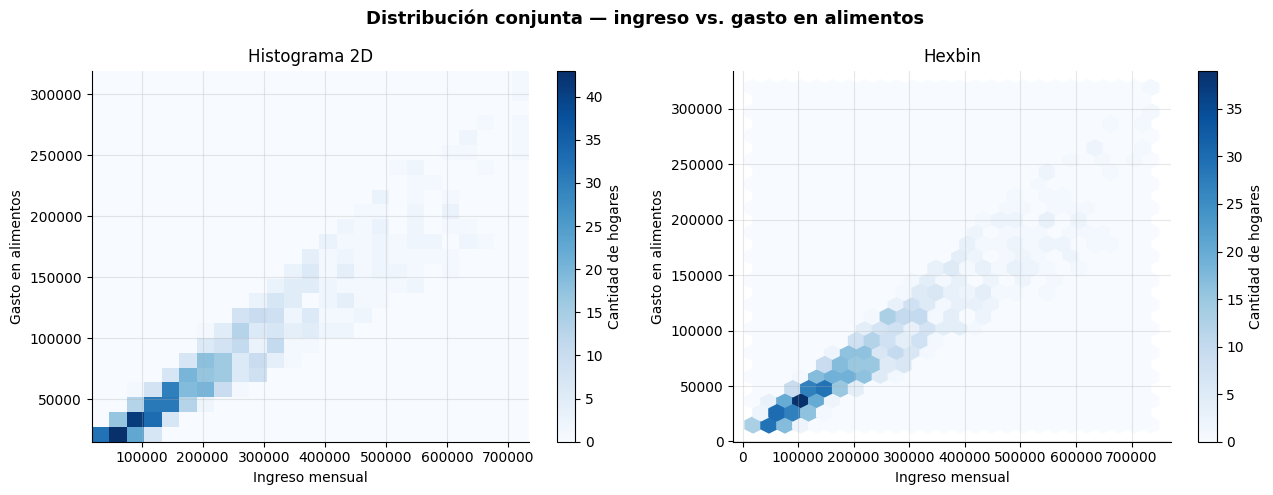

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# hist2d: bins cuadrados — cada celda es un cuadrado con color por densidad
h = axes[0].hist2d(df_viz['ingreso_mensual'],
                   df_viz['gasto_alimentos'],
                   bins=25, cmap='Blues')
plt.colorbar(h[3], ax=axes[0], label='Cantidad de hogares')
axes[0].set_title('Histograma 2D')
axes[0].set_xlabel('Ingreso mensual')
axes[0].set_ylabel('Gasto en alimentos')

# hexbin: bins hexagonales — tesela más eficiente el plano
hb = axes[1].hexbin(df_viz['ingreso_mensual'],
                    df_viz['gasto_alimentos'],
                    gridsize=25, cmap='Blues')
plt.colorbar(hb, ax=axes[1], label='Cantidad de hogares')
axes[1].set_title('Hexbin')
axes[1].set_xlabel('Ingreso mensual')
axes[1].set_ylabel('Gasto en alimentos')

plt.suptitle('Distribución conjunta — ingreso vs. gasto en alimentos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** Cuando el scatter tiene demasiados puntos superpuestos, el hist2d o hexbin muestra la densidad en lugar de los puntos individuales. Las zonas más oscuras concentran más hogares. La concentración en la esquina inferior izquierda confirma que la mayoría de los hogares tiene ingreso bajo-medio y gasto en alimentos bajo. El hexbin tesela el plano más eficientemente que los cuadrados del hist2d.

---

## — Personalización: leyendas, anotaciones y líneas de referencia

> **Síntesis teórica**
>
> - **`ax.legend()`**: leyenda de los elementos. El `label=` en cada `plot` o `scatter` define el texto.
> - **`ax.text(x, y, texto)`**: texto en coordenadas del sistema de datos.
> - **`ax.annotate()`**: texto con flecha apuntando a un punto específico.
> - **`ax.axvline(x)` / `ax.axhline(y)`**: líneas verticales y horizontales de referencia.
> - **`ax.set_xlim()` / `ax.set_ylim()`**: rango visible de cada eje.

### 4.1 Leyendas — posición y estilo

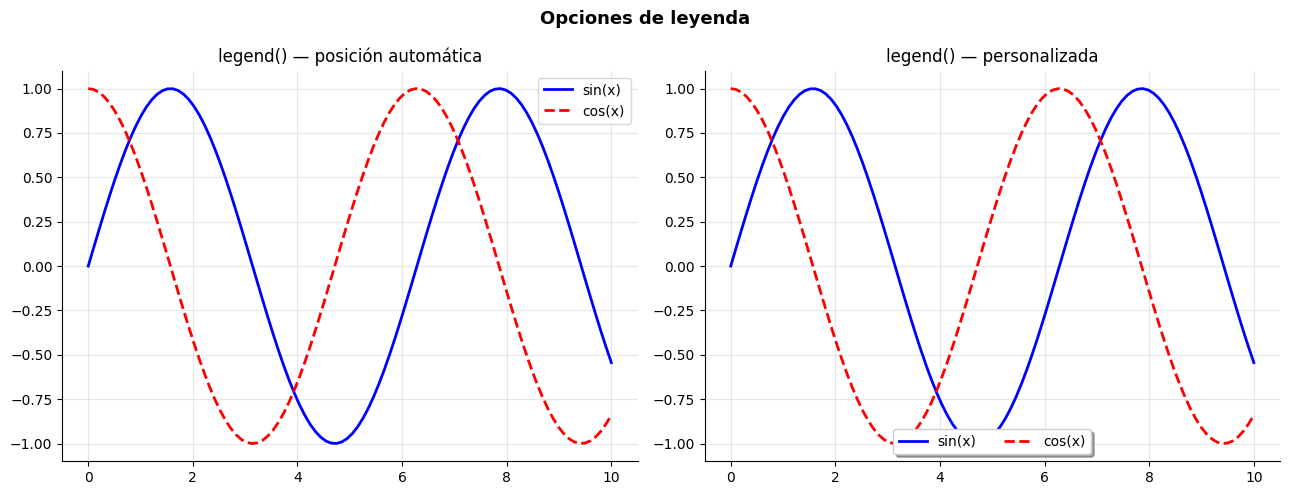

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.linspace(0, 10, 100)

# Panel izquierdo: leyenda automática
axes[0].plot(x, np.sin(x), '-b', label='sin(x)', linewidth=2)
axes[0].plot(x, np.cos(x), '--r', label='cos(x)', linewidth=2)
axes[0].legend()               # loc='best' por defecto
axes[0].set_title("legend() — posición automática")

# Panel derecho: leyenda personalizada
axes[1].plot(x, np.sin(x), '-b', label='sin(x)', linewidth=2)
axes[1].plot(x, np.cos(x), '--r', label='cos(x)', linewidth=2)
axes[1].legend(
    loc='lower center',   # posición: 'upper left', 'lower right', 'best', etc.
    ncol=2,               # columnas dentro de la leyenda
    frameon=True,         # caja alrededor
    fancybox=True,        # esquinas redondeadas
    shadow=True,          # sombra
    fontsize=10
)
axes[1].set_title("legend() — personalizada")

plt.suptitle('Opciones de leyenda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** `loc='best'` es la opción más segura — Matplotlib elige la posición que menos tapa los datos. `ncol=2` distribuye los items de la leyenda en dos columnas. `frameon=False` elimina la caja de la leyenda para un aspecto más limpio.

### 4.2 Texto y anotaciones con flecha

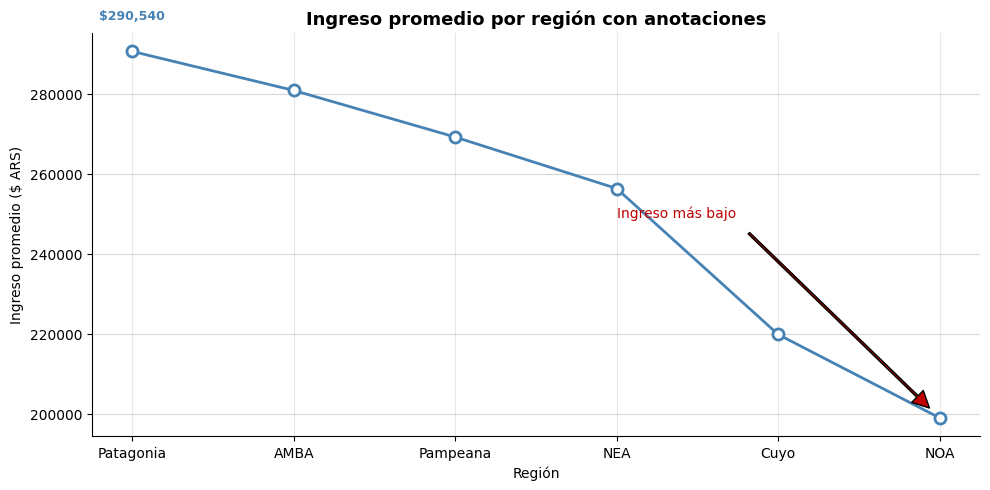

In [ ]:
ingreso_region = (df.groupby('region')['ingreso_mensual']
                  .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ingreso_region.index, ingreso_region.values,
        marker='o', linewidth=2, color='steelblue',
        markersize=8, markerfacecolor='white',
        markeredgecolor='steelblue', markeredgewidth=2)

# ax.text: texto simple en coordenadas del sistema de datos
ax.text(0,                            # posición X
        ingreso_region.iloc[0] + 8000,  # posición Y
        f'${ingreso_region.iloc[0]:,.0f}',  # texto
        ha='center', fontsize=9, color='steelblue', fontweight='bold')

# ax.annotate: texto con flecha apuntando a un punto
ax.annotate('Ingreso más bajo',              # texto
            xy=(ingreso_region.index[-1],    # punto señalado (flecha apunta acá)
                ingreso_region.iloc[-1]),
            xytext=(3,                       # posición del texto
                    ingreso_region.iloc[-1] + 50000),
            fontsize=10, color='#C00000',
            arrowprops=dict(
                facecolor='#C00000',   # color de la flecha
                shrink=0.05,           # reduce la flecha para no tapar el punto
                width=1.5              # grosor de la flecha
            ))

ax.set_title('Ingreso promedio por región con anotaciones',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Región')
ax.set_ylabel('Ingreso promedio ($ ARS)')
ax.yaxis.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

> **Interpretación:** `ax.text()` pone texto en coordenadas del sistema de datos — si hacés zoom el texto se mueve con el gráfico. `ax.annotate()` agrega una flecha desde `xytext` (donde está el texto) hacia `xy` (el punto señalado). `shrink=0.05` acorta ligeramente la flecha para que no tape el punto de datos.

### 4.3 Líneas de referencia — axvline y axhline

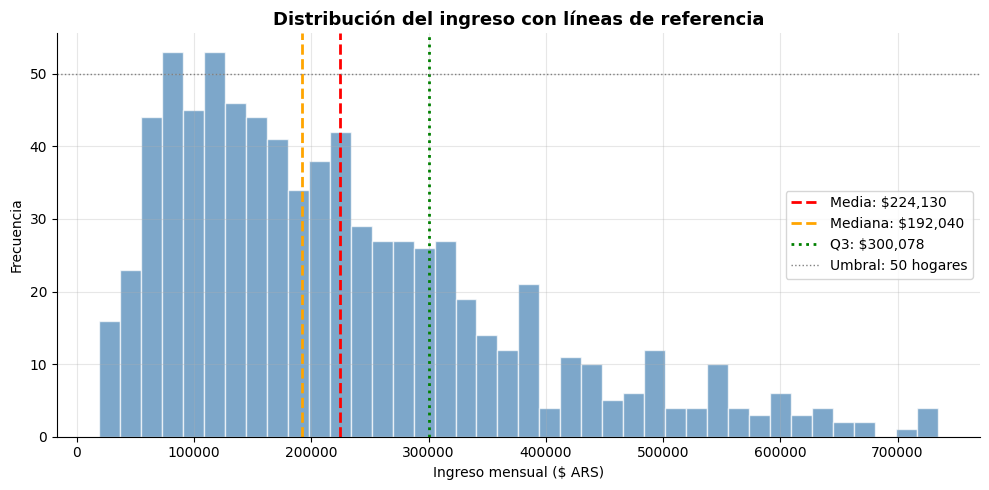

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_viz['ingreso_mensual'], bins=40,
        color='steelblue', edgecolor='white', alpha=0.7)

media   = df_viz['ingreso_mensual'].mean()
mediana = df_viz['ingreso_mensual'].median()
q3      = df_viz['ingreso_mensual'].quantile(0.75)

# axvline: línea vertical a lo largo de todo el alto del gráfico
ax.axvline(media,   color='red',    linestyle='--', linewidth=2,
           label=f'Media: ${media:,.0f}')
ax.axvline(mediana, color='orange', linestyle='--', linewidth=2,
           label=f'Mediana: ${mediana:,.0f}')
ax.axvline(q3,      color='green',  linestyle=':',  linewidth=2,
           label=f'Q3: ${q3:,.0f}')

# axhline: línea horizontal — útil para marcar umbrales
ax.axhline(50, color='gray', linestyle=':', linewidth=1,
           label='Umbral: 50 hogares')

ax.set_title('Distribución del ingreso con líneas de referencia',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ingreso mensual ($ ARS)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

> **Interpretación:** `axvline` y `axhline` trazan líneas que atraviesan todo el gráfico en el valor indicado. Se pueden combinar con `label=` para que aparezcan en la leyenda con el valor concreto. Son las herramientas más directas para agregar contexto estadístico — media, mediana, percentiles, umbrales — directamente sobre el gráfico.

---

##  — Subplots: múltiples paneles

> **Síntesis teórica**
>
> **`plt.subplots(nrows, ncols)`** — grilla regular. La más común. Retorna `fig` y un array de `axes`.
>
> **`fig.subplots_adjust(hspace, wspace)`** — controla el espaciado entre paneles.
>
> **`plt.GridSpec(rows, cols)`** — grilla irregular. Paneles que ocupan distintos espacios.
>
> Parámetros útiles de `plt.subplots`:
> - `sharex='col'`: paneles de la misma columna comparten eje X.
> - `sharey='row'`: paneles de la misma fila comparten eje Y.
> - `figsize=(ancho, alto)`: tamaño total de la figura.

### 5.1 plt.subplots — grilla regular con axes.flat

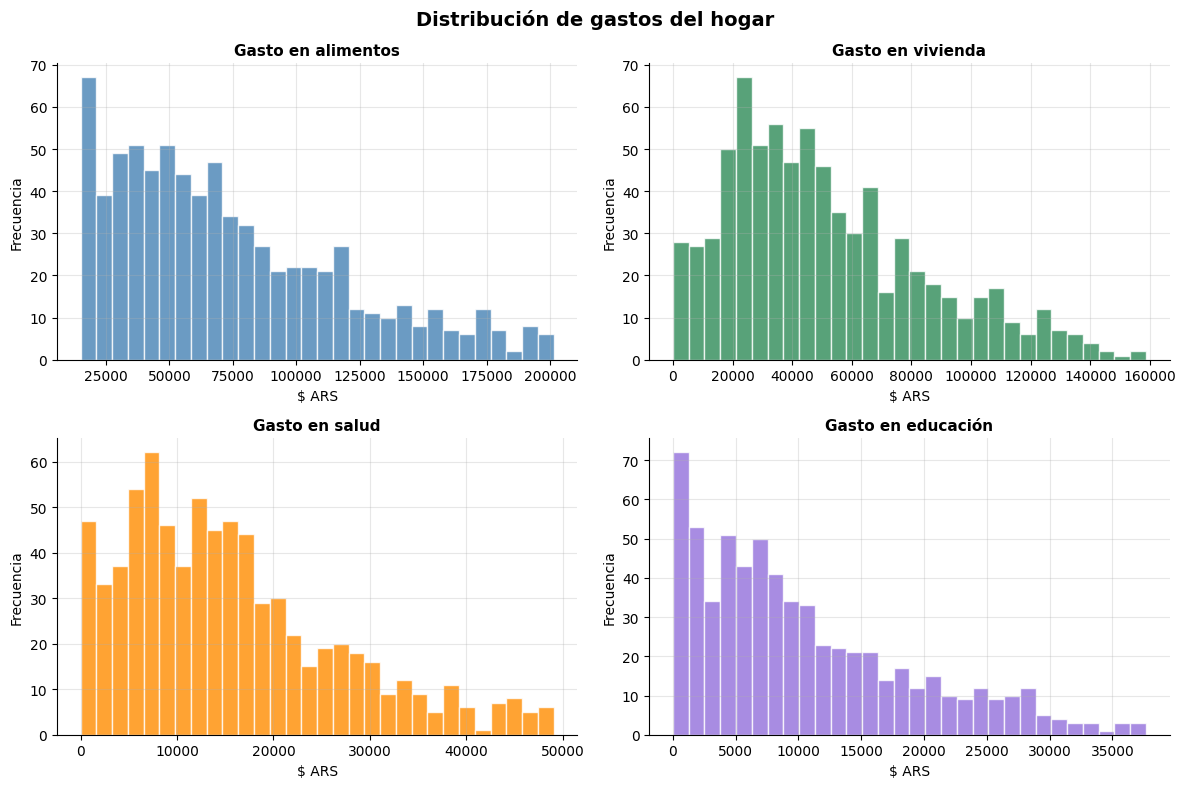

In [ ]:
vars_gasto = ['gasto_alimentos', 'gasto_vivienda', 'gasto_salud', 'gasto_educacion']
titulos    = ['Gasto en alimentos', 'Gasto en vivienda', 'Gasto en salud', 'Gasto en educación']
colores    = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

# subplots con grilla 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

# axes.flat convierte el array 2D en un iterador lineal — un solo loop para todos los paneles
for ax, var, titulo, color in zip(axes.flat, vars_gasto, titulos, colores):
    datos = df_viz[var].dropna()
    datos = datos[datos < datos.quantile(0.97)]
    ax.hist(datos, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('$ ARS')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de gastos del hogar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretación:** `axes.flat` es la clave para iterar sobre una grilla de cualquier forma sin código adicional. Sin `flat`, `axes` es un array 2D y habría que indexarlo como `axes[0][0]`, `axes[0][1]`, etc. Con `flat` se convierte en una secuencia lineal que se puede recorrer con un solo `for`.

### 5.2 subplots_adjust — espaciado entre paneles

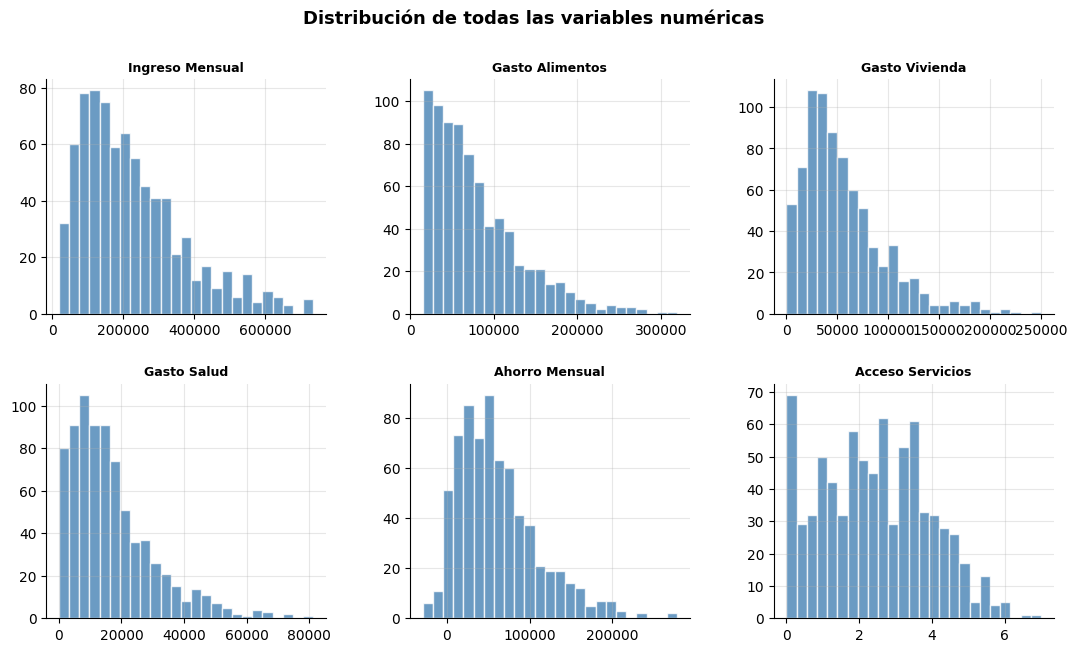

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

# subplots_adjust controla el espacio entre paneles
# hspace: espacio vertical entre filas (fracción del alto de cada panel)
# wspace: espacio horizontal entre columnas (fracción del ancho)
fig.subplots_adjust(hspace=0.3, wspace=0.3)

variables = ['ingreso_mensual', 'gasto_alimentos', 'gasto_vivienda',
             'gasto_salud', 'ahorro_mensual', 'acceso_servicios']

for ax, var in zip(axes.flat, variables):
    datos = df_viz[var].dropna()
    ax.hist(datos, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(var.replace('_', ' ').title(), fontsize=9, fontweight='bold')

plt.suptitle('Distribución de todas las variables numéricas',
             fontsize=13, fontweight='bold')
plt.show()

> **Interpretación:** `subplots_adjust` da control preciso sobre el espaciado. `hspace=0.4` significa que el espacio vertical entre paneles es el 40% del alto de cada panel. La alternativa `plt.tight_layout()` ajusta automáticamente — es más conveniente pero menos precisa.

### 5.3 GridSpec — grilla irregular

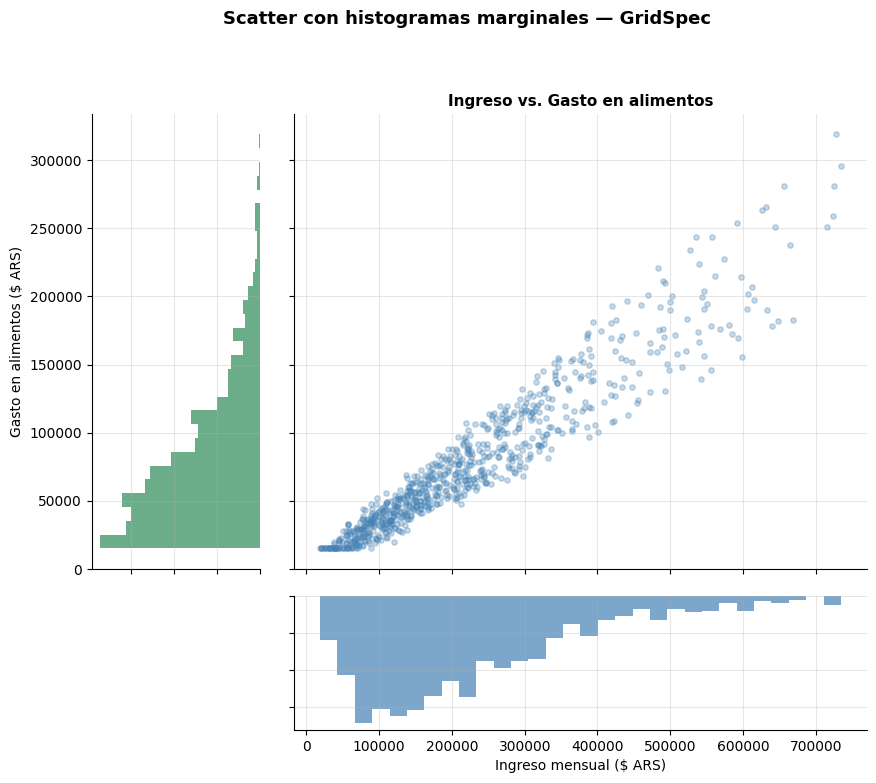

In [ ]:
fig = plt.figure(figsize=(10, 8))

# GridSpec define una grilla de 4x4
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)

# El panel principal ocupa filas 0-2, columnas 1-3
main_ax = fig.add_subplot(grid[0:3, 1:])

# El histograma lateral ocupa filas 0-2, columna 0
y_hist = fig.add_subplot(grid[0:3, 0], xticklabels=[])

# El histograma inferior ocupa fila 3, columnas 1-3
x_hist = fig.add_subplot(grid[3, 1:], yticklabels=[])

x_data = df_viz['ingreso_mensual']
y_data = df_viz['gasto_alimentos']

# Panel principal: scatter
main_ax.scatter(x_data, y_data, alpha=0.3, color='steelblue', s=15)
main_ax.set_title('Ingreso vs. Gasto en alimentos', fontsize=11, fontweight='bold')
main_ax.xaxis.set_major_formatter(plt.NullFormatter())
main_ax.yaxis.set_major_formatter(plt.NullFormatter())

# Histograma inferior: distribución del ingreso
x_hist.hist(x_data, bins=30, orientation='vertical', color='steelblue', alpha=0.7)
x_hist.invert_yaxis()
x_hist.set_xlabel('Ingreso mensual ($ ARS)')

# Histograma lateral: distribución del gasto
y_hist.hist(y_data, bins=30, orientation='horizontal', color='seagreen', alpha=0.7)
y_hist.invert_xaxis()
y_hist.set_ylabel('Gasto en alimentos ($ ARS)')

plt.suptitle('Scatter con histogramas marginales — GridSpec',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

> **Interpretación:** `GridSpec` usa indexación tipo NumPy: `grid[0:3, 1:]` significa filas 0 a 2 (inclusive) y columnas 1 hasta el final. El resultado es un scatter con histogramas marginales que muestra simultáneamente la relación entre variables y la distribución individual de cada una — sin necesidad de ninguna librería adicional.

---

## Resumen: interfaces y funciones

### Las dos interfaces — cuándo usar cada una

| Situación | Interfaz recomendada |
|---|---|
| Gráfico rápido de exploración, un solo panel | MATLAB (`plt.`) |
| Dos o más paneles | Orientada a objetos (`fig, ax`) |
| Modificar el gráfico después de crearlo | Orientada a objetos |
| Guardar la figura o combinarla con otras | Orientada a objetos |

### Funciones principales

| Función | Uso | Interfaz equivalente |
|---|---|---|
| `ax.plot()` | Líneas | `plt.plot()` |
| `ax.scatter()` | Dispersión | `plt.scatter()` |
| `ax.hist()` | Histograma | `plt.hist()` |
| `ax.hist2d()` | Histograma 2D | `plt.hist2d()` |
| `ax.hexbin()` | Hexbin | `plt.hexbin()` |
| `ax.axvline()` | Línea vertical | `plt.axvline()` |
| `ax.axhline()` | Línea horizontal | `plt.axhline()` |
| `ax.annotate()` | Flecha + texto | `plt.annotate()` |
| `ax.set_title()` | Título | `plt.title()` |
| `ax.set_xlabel()` | Etiqueta X | `plt.xlabel()` |
| `ax.legend()` | Leyenda | `plt.legend()` |
| `plt.subplots()` | Múltiples paneles | — |
| `plt.GridSpec()` | Paneles irregulares | — |